First we need to inspectionate the dataset.

In [3]:
import pandas as pd

train_df = pd.read_csv("dataset/data.csv")
validation_df = pd.read_csv("dataset/validation_data.csv")

print("TRAIN DATA:")
print(train_df.head())
print("\nVALIDATION DATA:")
print(validation_df.head())

print("\nINFO TRAIN:")
print(train_df.info())

print("\nINFO VALIDATION:")
print(validation_df.info())

print("\nShape train:", train_df.shape)
print("Shape validation:", validation_df.shape)

print("\nLabel distribution in train:")
print(train_df["label"].value_counts())

print("\nNull values in train:")
print(train_df.isnull().sum())

print("\nNull Values in validation:")
print(validation_df.isnull().sum())

TRAIN DATA:
   label                                              title  \
0      1  As U.S. budget fight looms, Republicans flip t...   
1      1  U.S. military to accept transgender recruits o...   
2      1  Senior U.S. Republican senator: 'Let Mr. Muell...   
3      1  FBI Russia probe helped by Australian diplomat...   
4      1  Trump wants Postal Service to charge 'much mor...   

                                                text       subject  \
0  WASHINGTON (Reuters) - The head of a conservat...  politicsNews   
1  WASHINGTON (Reuters) - Transgender people will...  politicsNews   
2  WASHINGTON (Reuters) - The special counsel inv...  politicsNews   
3  WASHINGTON (Reuters) - Trump campaign adviser ...  politicsNews   
4  SEATTLE/WASHINGTON (Reuters) - President Donal...  politicsNews   

                 date  
0  December 31, 2017   
1  December 29, 2017   
2  December 31, 2017   
3  December 30, 2017   
4  December 29, 2017   

VALIDATION DATA:
   label                  

Then we are going to find out the accuracy, precision, recall and f1 score.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

train_df["content"] = train_df["title"] + " " + train_df["text"]

X = train_df["content"]
y = train_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9877331330579547

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      3996
           1       0.98      0.99      0.99      3993

    accuracy                           0.99      7989
   macro avg       0.99      0.99      0.99      7989
weighted avg       0.99      0.99      0.99      7989



In [20]:
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

top_real = sorted(zip(coefficients, feature_names), reverse=True)[:10]
top_fake = sorted(zip(coefficients, feature_names))[:10]

print("Top REAL words:")
for coef, word in top_real:
    print(word, coef)

print("\nTop FAKE words:")
for coef, word in top_fake:
    print(word, coef)

Top REAL words:
says 7.409397052274343
factbox 5.203711456998472
china 3.8640365844814046
house 3.626276756697246
senate 3.5938433460193346
talks 3.45938287186462
urges 3.3102218068328466
seeks 3.284076323631027
eu 3.200036672655361
lawmakers 3.131748217739682

Top FAKE words:
video -18.893907895508203
watch -8.741906910404659
hillary -8.426417465603896
breaking -8.317973886199534
gop -8.246527505468237
just -8.101415113867324
tweets -5.110805641694695
racist -4.389982890214407
details -4.288905322172859
america -4.142520627663326


The result obtained looks not real for a first performance. It seems there´s data leakage due to patterns like "Reuters".
We are going to clean "Reuters" and perform again to see if a more realistic result its given.

In [ ]:
import re

def clean_text(text):
    text = re.sub(r"\(Reuters\)", "", text)
    return text

train_df["text_clean"] = train_df["text"].apply(clean_text)
train_df["content"] = train_df["title"] + " " + train_df["text_clean"]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

train_df["content"] = train_df["title"] + " " + train_df["text"]

X = train_df["title"]
y = train_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9405432469645763

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.92      0.94      3996
           1       0.93      0.96      0.94      3993

    accuracy                           0.94      7989
   macro avg       0.94      0.94      0.94      7989
weighted avg       0.94      0.94      0.94      7989



After cleaning this bias, performance adjusted to a more realistic level.

After this we decided to add extra help to the model for understanding the dataset by adding some features such as subject to understand better the words and also adding ngram_range that helps the model to understand word combinations.

In [16]:
train_df["content"] = (
    train_df["title"] + " " +
    train_df["text_clean"] + " " +
    train_df["subject"]
)

vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    ngram_range=(1,2) 
)

In [19]:
X = train_df["content"]

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9414194517461509

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.92      0.94      3996
           1       0.93      0.96      0.94      3993

    accuracy                           0.94      7989
   macro avg       0.94      0.94      0.94      7989
weighted avg       0.94      0.94      0.94      7989



As we can see the accuracy didn't improve much and we come to the conclusion that text + title gives enough information ans subject it's not useful.

In [21]:
# Cargar validation
validation_df = pd.read_csv("dataset/validation_data.csv")

# Limpiar texto igual que antes
validation_df["text_clean"] = validation_df["text"].apply(clean_text)

# Crear content
validation_df["content"] = (
    validation_df["title"] + " " +
    validation_df["text_clean"] + " " +
    validation_df["subject"]
)

# Transformar con el MISMO vectorizer
X_val = vectorizer.transform(validation_df["content"])

# Predecir
validation_df["label"] = model.predict(X_val)

# Guardar CSV
validation_df.to_csv("predictions.csv", index=False)

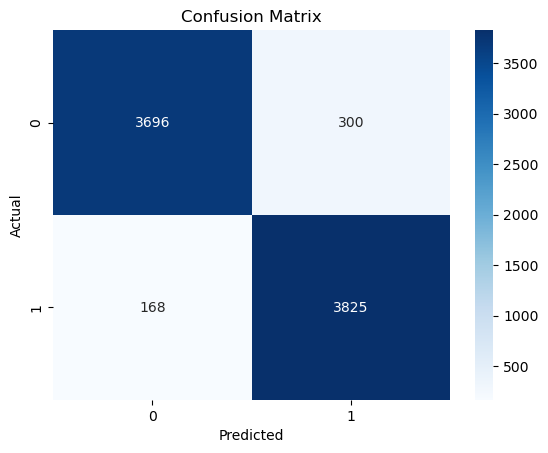

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

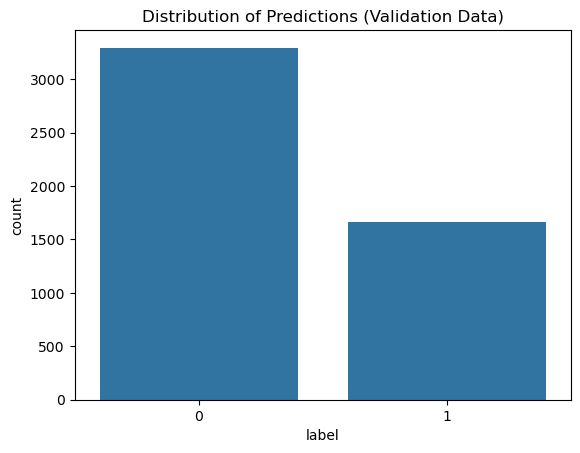

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pred_df = pd.read_csv("predictions.csv")

sns.countplot(x="label", data=pred_df)
plt.title("Distribution of Predictions (Validation Data)")
plt.show()

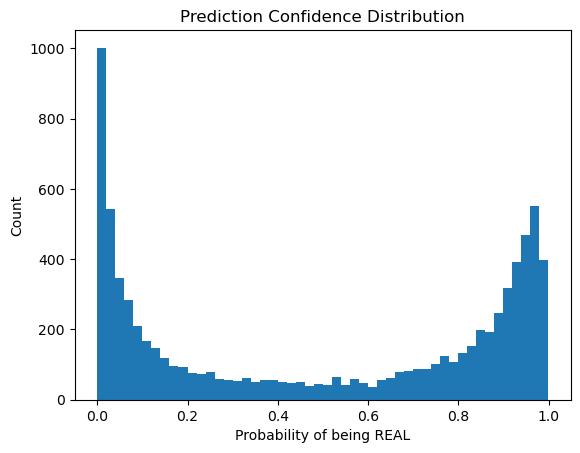

In [24]:
y_probs = model.predict_proba(X_test_tfidf)[:, 1]

plt.hist(y_probs, bins=50)
plt.title("Prediction Confidence Distribution")
plt.xlabel("Probability of being REAL")
plt.ylabel("Count")
plt.show()

In [25]:
errors = pd.DataFrame({
    "text": X_test,
    "true": y_test,
    "pred": y_pred
})

errors = errors[errors["true"] != errors["pred"]]

print(errors.head(5))

                                                    text  true  pred
8726   Art of the spin: Trump bankers question his po...     1     0
6024   Trump may reinstate secret CIA 'black site' pr...     1     0
35152  IRAN MAY RELEASE 3 AMERICAN PRISONERS/HOSTAGES...     0     1
28045   ‘Safe’ Nuclear Power Plant Continues To Leak ...     0     1
252    Blackwater founder Prince details meeting with...     1     0


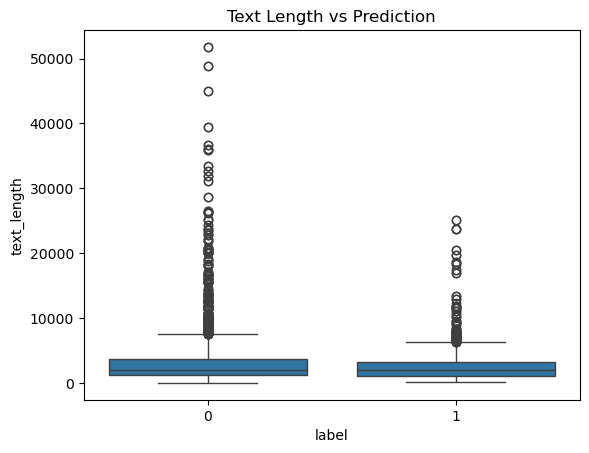

In [26]:
pred_df["text_length"] = pred_df["text"].apply(len)

sns.boxplot(x="label", y="text_length", data=pred_df)
plt.title("Text Length vs Prediction")
plt.show()

In [3]:
import pandas as pd
import re
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# 1. Cargar datos
train_df = pd.read_csv("dataset/data.csv")

# 2. Limpiar texto
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"\(reuters\)", "", text)
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df["title_clean"] = train_df["title"].apply(clean_text)
train_df["text_clean"] = train_df["text"].apply(clean_text)

# 3. Crear contenido
train_df["content"] = (
    train_df["title_clean"] + " " +
    train_df["text_clean"] + " " +
    train_df["subject"].astype(str).str.lower()
)

# 4. Variables
X = train_df["content"]
y = train_df["label"]

# 5. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. TF-IDF
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# 7. Modelo
tfidf_model = LogisticRegression(max_iter=1000)
tfidf_model.fit(X_train_tfidf, y_train)

# 8. Extraer palabras importantes
feature_names = tfidf_vectorizer.get_feature_names_out()
coefficients = tfidf_model.coef_[0]

top_real_idx = np.argsort(coefficients)[-10:]
top_fake_idx = np.argsort(coefficients)[:10]

print("Top REAL words:")
for i in reversed(top_real_idx):
    print(feature_names[i], coefficients[i])

print("\nTop FAKE words:")
for i in top_fake_idx:
    print(feature_names[i], coefficients[i])

Top REAL words:
politicsnews 15.061583670038045
said 14.693685813992971
worldnews 9.565020518313148
washington 6.180059092681662
reuters 5.887611527261797
president donald 5.1482094938721366
wednesday 4.490670077913053
republican 4.488336621053828
tuesday 4.353093112322518
thursday 3.932617880936388

Top FAKE words:
politics -11.134177466172993
news -8.564522080285023
video -8.330871914760607
just -6.651003968772214
government news -6.018998078553892
image -5.546555516156601
gop -5.52081740109716
featured image -5.260924493171855
president trump -5.248299627710425
featured -5.216699762188847
